## DATA LOADING AND PREPROCESSING

In [1]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

### Merge Strategy

Before feature extraction, we needed to combine the accelerometer and gyroscope signals for each recording.

Sensors used: Accelerometer (ax, ay, az) and Gyroscope (gx, gy, gz)

Issue: Row counts differed slightly (450–600 rows per recording) due to independent sensor timing and OS scheduling, even though both were recorded at 50 Hz.

Solution: We merged the sensors using nearest-neighbor timestamp matching based on the seconds_elapsed column.

Result: A clean, aligned time-series per recording with the following format:

| seconds_elapsed | ax | ay | az | gx | gy | gz | activity

This ensures temporal consistency and preserves sequential integrity for HMM modeling.

In [2]:
DATA_PATH = "data"

In [3]:
all_samples = []

In [4]:
for participant in os.listdir(DATA_PATH):
    participant_path = os.path.join(DATA_PATH, participant)
    
    if not os.path.isdir(participant_path):
        continue
    
    for recording in os.listdir(participant_path):
        recording_path = os.path.join(participant_path, recording)
        
        accel_path = os.path.join(recording_path, "Accelerometer.csv")
        gyro_path = os.path.join(recording_path, "Gyroscope.csv")
        
        if not os.path.exists(accel_path) or not os.path.exists(gyro_path):
            continue
        
        # Load data
        accel = pd.read_csv(accel_path)
        gyro = pd.read_csv(gyro_path)
        
        # Keep necessary columns
        accel = accel[["seconds_elapsed", "x", "y", "z"]]
        gyro = gyro[["seconds_elapsed", "x", "y", "z"]]
        
        # Rename columns
        accel.rename(columns={"x":"ax", "y":"ay", "z":"az"}, inplace=True)
        gyro.rename(columns={"x":"gx", "y":"gy", "z":"gz"}, inplace=True)
        
        # Sort by time
        accel.sort_values("seconds_elapsed", inplace=True)
        gyro.sort_values("seconds_elapsed", inplace=True)
        
        # Merge using nearest timestamp
        merged = pd.merge_asof(
            accel,
            gyro,
            on="seconds_elapsed",
            direction="nearest"
        )
        
        # Compute duration
        duration = merged["seconds_elapsed"].max() - merged["seconds_elapsed"].min()
        
        # Extract activity label from folder name
        activity = recording.split("-")[0]
        
        merged["activity"] = activity
        
        all_samples.append({
            "data": merged,
            "activity": activity,
            "participant": participant,
            "duration": duration
        })

print(f"Total recordings loaded: {len(all_samples)}")

Total recordings loaded: 50


In [5]:
durations = [sample["duration"] for sample in all_samples]
print("Min duration:", min(durations))
print("Max duration:", max(durations))

Min duration: 7.720366943359376
Max duration: 11.813686767578124


In [6]:
activities = [sample["activity"] for sample in all_samples]
print(Counter(activities))

Counter({'Jump': 13, 'Walk': 13, 'Stand': 12, 'Still': 12})


In [7]:
merged.head()

,seconds_elapsed,ax,ay,az,gx,gy,gz,activity
0,0.294608,0.252918,0.768914,0.447187,-0.135438,0.404938,-0.195112,Walk
1,0.314664,0.165534,0.655931,0.511350,-0.234437,0.300575,-0.217525,Walk
2,0.334720,0.052428,0.354345,0.781880,-0.264275,0.334675,-0.234575,Walk
3,0.354776,0.057142,0.384276,0.931904,-0.232375,0.481663,-0.241038,Walk
4,0.374832,-0.147886,0.246621,0.606323,-0.119350,0.482762,-0.278300,Walk


## Windowing Strategy

To convert each continuous recording into fixed-length sequences suitable for feature extraction and HMM training:

Window Size: 2 seconds (100 samples at 50 Hz)

Overlap: 50% (50 samples shift between windows)

Reasoning:

1. Captures full cycles of walking (~1–2 Hz)

2. Stabilizes variance for standing and still activities

3. Retains resolution for frequency-domain analysis such as FFT

4. Overlapping windows increase the number of training sequences

Results:

1. Each 10-second recording produced ~9 windows

2. With 50 recordings, the dataset contains approximately 450 feature windows ready for feature extraction

In [8]:
def window_data(df, window_size=100, overlap=50):
    """
    df: merged dataframe with columns ['seconds_elapsed','ax','ay','az','gx','gy','gz','activity','participant']
    window_size: number of samples per window
    overlap: number of samples to overlap
    """
    windows = []
    start = 0
    end = window_size
    
    while end <= len(df):
        window_df = df.iloc[start:end].copy()
        
        # Store window data and labels
        windows.append({
            "ax": window_df["ax"].values,
            "ay": window_df["ay"].values,
            "az": window_df["az"].values,
            "gx": window_df["gx"].values,
            "gy": window_df["gy"].values,
            "gz": window_df["gz"].values,
            "activity": window_df["activity"].iloc[0]
        })
        
        start += (window_size - overlap)
        end = start + window_size
    
    return windows

In [9]:
all_windows = []

In [10]:
for sample in all_samples:
    merged_df = sample["data"]
    windows = window_data(merged_df, window_size=100, overlap=50)
    all_windows.extend(windows)

print(f"Total windows created: {len(all_windows)}")

Total windows created: 398


In [11]:
activities = [w["activity"] for w in all_windows]
print(Counter(activities))

Counter({'Walk': 104, 'Jump': 100, 'Stand': 99, 'Still': 95})


In [13]:
all_windows[0]

{'ax': array([0.31461143, 0.24303293, 0.25404787, 0.26084805, 0.26848269,
        0.27132845, 0.26529884, 0.25320816, 0.24195385, 0.22859573,
        0.25063562, 0.24715567, 0.24185228, 0.23457909, 0.22618818,
        0.21718311, 0.20797539, 0.19958019, 0.19210052, 0.18559122,
        0.17964792, 0.1750803 , 0.17139196, 0.16848564, 0.16555071,
        0.16191053, 0.15896797, 0.15606117, 0.15332508, 0.15084982,
        0.14897871, 0.14663839, 0.14420176, 0.14223528, 0.14021873,
        0.13849545, 0.13714266, 0.13639736, 0.13598251, 0.13646555,
        0.13693476, 0.13828564, 0.13993931, 0.14159775, 0.1432457 ,
        0.14562798, 0.14796305, 0.14985037, 0.15117645, 0.15124559,
        0.15124846, 0.15023041, 0.14816141, 0.14601421, 0.14385414,
        0.14141846, 0.13850117, 0.13656473, 0.1356945 , 0.13566494,
        0.13586283, 0.13737202, 0.13947344, 0.14235878, 0.14594364,
        0.15060997, 0.15640497, 0.16130733, 0.16508484, 0.16803885,
        0.17063856, 0.17165565, 0.17406797

### Data Visualization

In [14]:
# Select a sample for each activity
activities = ["Stand", "Walk", "Jump", "Still"]

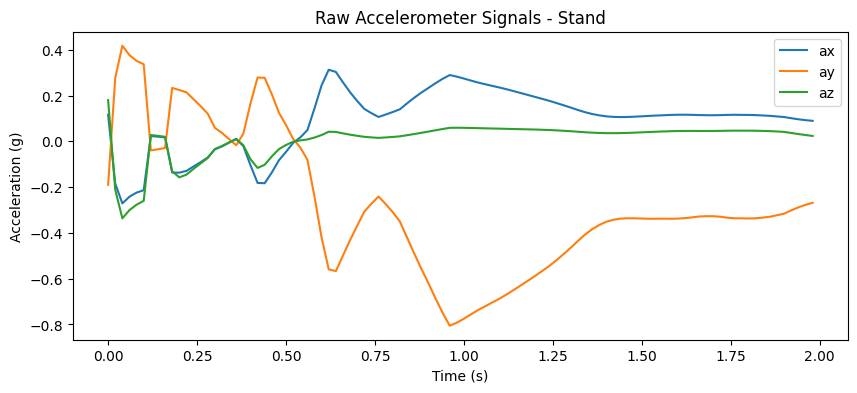

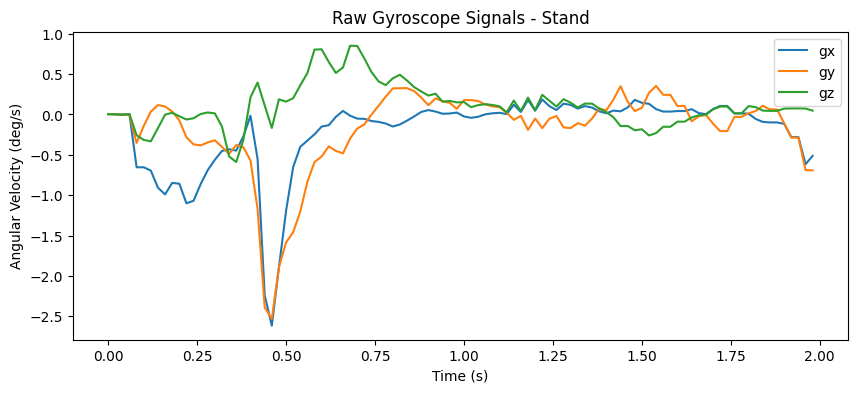

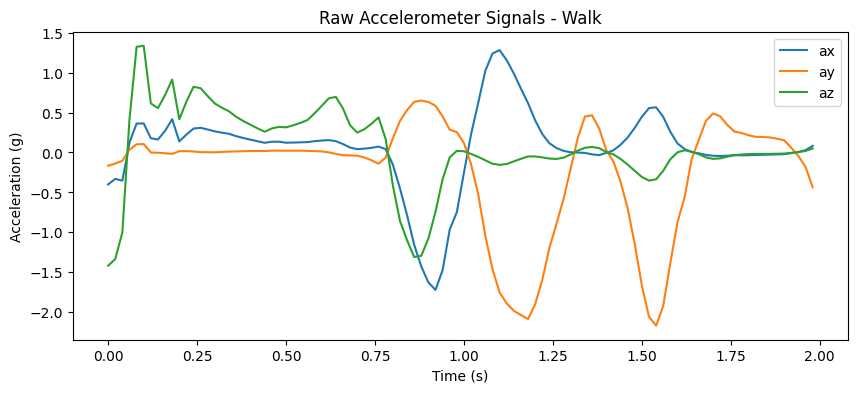

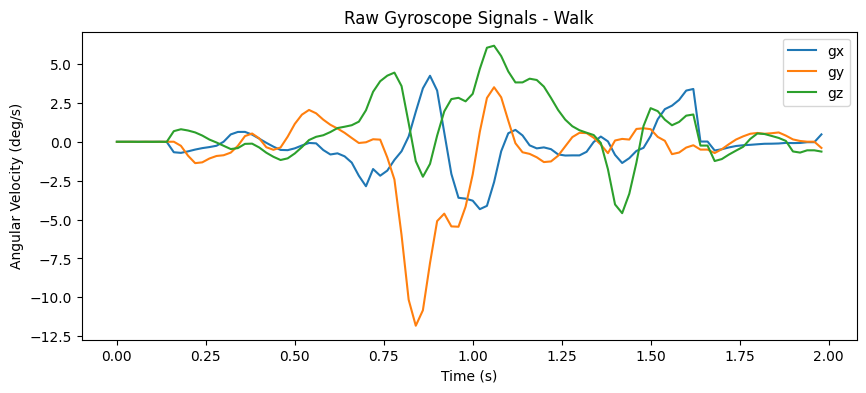

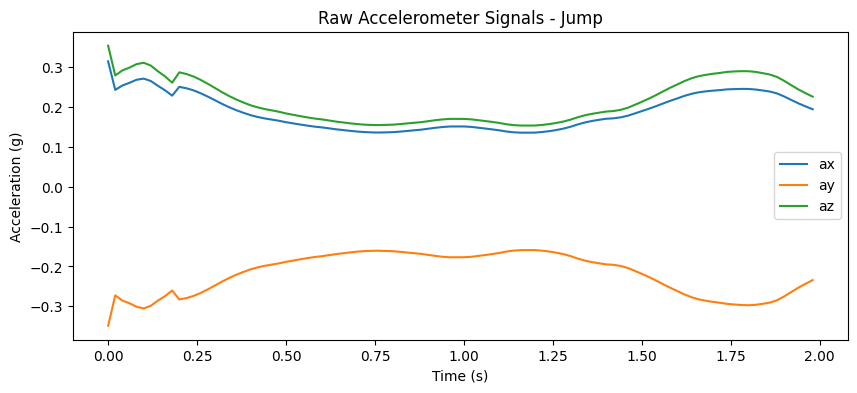

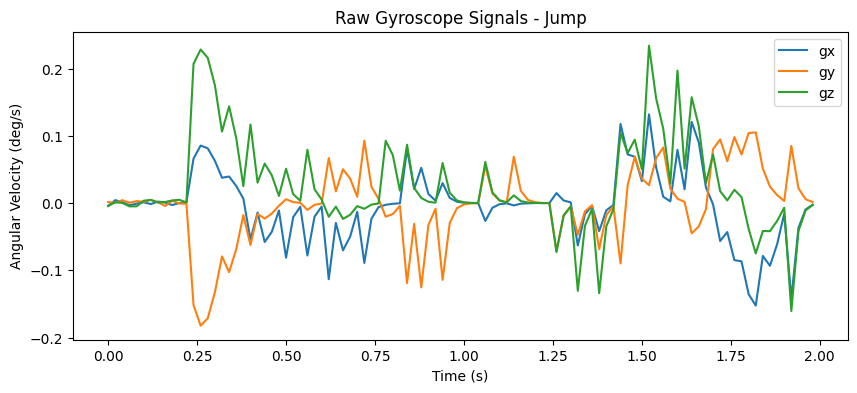

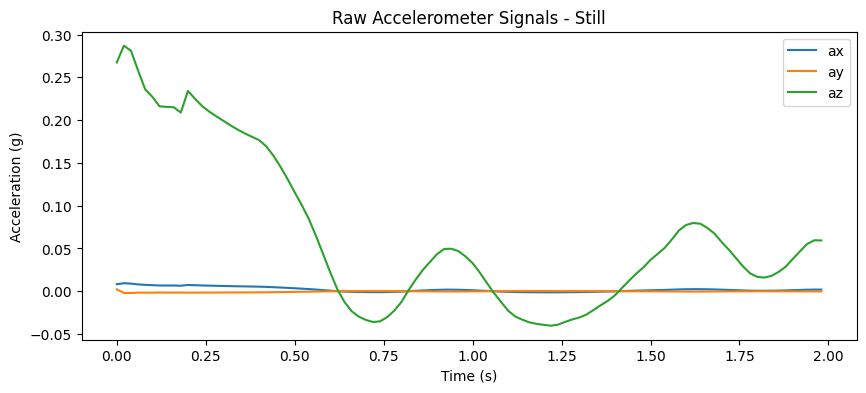

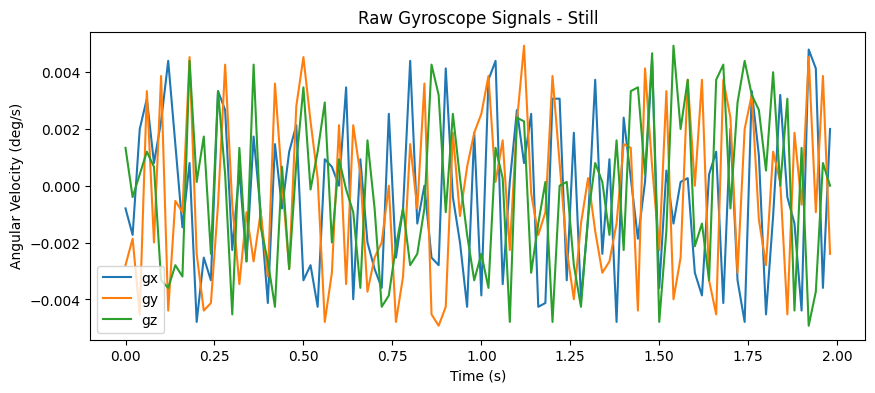

In [18]:
for act in activities:
    # Find first window of this activity
    sample = next(f for f in all_windows if f["activity"] == act)
    
    # Create a time vector based on sampling rate
    fs = 50  # 50 Hz sampling
    n_samples = len(sample["ax"])
    t = np.arange(n_samples) / fs  # time in seconds

    # Plot accelerometer
    plt.figure(figsize=(10,4))
    plt.plot(t, sample["ax"], label="ax")
    plt.plot(t, sample["ay"], label="ay")
    plt.plot(t, sample["az"], label="az")
    plt.title(f"Raw Accelerometer Signals - {act}")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (g)")
    plt.legend()
    plt.show()

    # Plot gyroscope
    plt.figure(figsize=(10,4))
    plt.plot(t, sample["gx"], label="gx")
    plt.plot(t, sample["gy"], label="gy")
    plt.plot(t, sample["gz"], label="gz")
    plt.title(f"Raw Gyroscope Signals - {act}")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (deg/s)")
    plt.legend()
    plt.show()

## FEATURE EXTRACTION

### **Compute Accelerometer Magnitude**

To simplify the signals and capture overall motion intensity, we compute the magnitude of the accelerometer vector:  


a_mag = sqrt{ax^2 + ay^2 + az^2} 

This reduces x, y, z components into a single value representing overall acceleration per sample.  

In [ ]:
def compute_accel_magnitude(window):
    """
    Compute accelerometer magnitude for a window
    """
    return np.sqrt(window["ax"]**2 + window["ay"]**2 + window["az"]**2)

### **Compute Time-Domain Features**

Time-domain features capture motion intensity and variability:  

- **Accelerometer magnitude:** Mean, Variance, RMS (Root Mean Square), Signal Magnitude Area (SMA)  
- **Gyroscope:** Mean, Variance  

These features help distinguish activities:  

- **Standing/Still:** low variance  
- **Walking:** moderate variance and cyclical patterns  
- **Jumping:** high energy bursts  

In [ ]:
def compute_time_features(window):
    # Accelerometer magnitude
    a_mag = compute_accel_magnitude(window)
    mean_a = np.mean(a_mag)
    var_a = np.var(a_mag)
    rms_a = np.sqrt(np.mean(a_mag**2))
    sma_a = np.mean(np.abs(window["ax"]) + np.abs(window["ay"]) + np.abs(window["az"]))
    
    # Gyroscope features
    mean_g = np.mean([np.mean(window["gx"]), np.mean(window["gy"]), np.mean(window["gz"])])
    var_g = np.var([np.var(window["gx"]), np.var(window["gy"]), np.var(window["gz"])])
    
    return [mean_a, var_a, rms_a, sma_a, mean_g, var_g]

### **Compute Frequency-Domain Features**

Frequency-domain features capture periodicity of motion:  

- **Dominant Frequency:** frequency with maximum power in the FFT  
- **Spectral Energy:** sum of squared FFT components  

These features differentiate activities:

- **Walking:** clear dominant frequency (~1–2 Hz)  
- **Jumping:** high energy spikes  
- **Still/Standing:** very low spectral energy  

In [ ]:
def compute_fft_features(signal, fs=50):
    """
    Compute dominant frequency and spectral energy for a 1D signal
    fs: sampling frequency
    """
    fft_vals = np.fft.rfft(signal)
    fft_freq = np.fft.rfftfreq(len(signal), d=1/fs)
    
    spectral_energy = np.sum(np.abs(fft_vals)**2)
    dom_freq = fft_freq[np.argmax(np.abs(fft_vals))]
    
    return [dom_freq, spectral_energy]

### **Extract Features for All Windows**

We combine time-domain and frequency-domain features for each window to form a final feature vector.  
Each vector is labeled with the corresponding activity.  


In [ ]:
feature_list = []

for w in all_windows:
    # Time-domain features
    time_features = compute_time_features(w)
    
    # Accelerometer magnitude for FFT
    a_mag = compute_accel_magnitude(w)
    
    # Frequency-domain features
    freq_features = compute_fft_features(a_mag, fs=50)
    
    # Combine features
    feature_vector = time_features + freq_features
    
    feature_list.append({
        "features": feature_vector,
        "activity": w["activity"],
    })

### **Normalize Features (Z-score)**

Z-score normalization ensures that features with larger numerical ranges (e.g., SMA) do not dominate the HMM training. Normalization improves convergence in Gaussian HMMs and ensures that all features contribute proportionally.

In [ ]:
# Convert feature list to matrix
X = np.array([f["features"] for f in feature_list])
y = [f["activity"] for f in feature_list]

# Z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Convert feature list to a dataframe
df_features = pd.DataFrame([f["features"] for f in feature_list],
                           columns=["mean_a", "var_a", "rms_a", "sma_a", "mean_g", "var_g", "dom_freq", "spectral_energy"])

In [ ]:
# Add labels
df_features["activity"] = [f["activity"] for f in feature_list]

In [ ]:
# View first 5 rows
df_features.head()

,mean_a,var_a,rms_a,sma_a,mean_g,var_g,dom_freq,spectral_energy,activity
0,0.359158,0.007572,0.369548,0.620654,0.006094,9.292965e-07,0.0,1327.822951,Jump
1,1.391376,3.680491,2.369898,1.839143,-0.110427,4.158996e-01,0.0,37771.097073,Jump
2,3.933155,8.602481,4.906341,5.355494,-0.180875,1.196093e+01,0.0,197709.968997,Jump
3,5.324527,7.008350,5.946338,7.385155,-0.118118,4.906286e+01,0.0,318548.052527,Jump
4,5.024423,6.695173,5.651548,6.752153,-0.099481,1.246305e+02,0.0,285934.312848,Jump


In [ ]:
df_features.shape[0]

398

In [ ]:
df_features['activity'].value_counts()

activity
Walk     104
Jump     100
Stand     99
Still     95
Name: count, dtype: int64

In [ ]:
# Save the feature DataFrame to a CSV
df_features.to_csv("all_windows_features.csv", index=False)